<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Multiple Linear Regression



## Objectives

After completing this lab, you will be able to:

* Use scikit-learn to implement multiple linear regression
* Create, train, and test a multiple linear regression model on real data


### Import needed packages


For this lab, you will need to have the following packages:
 - NumPy
 - Matplotlib
 - Pandas
 - Scikit-learn

To avoid issues importing these libraries, you may execute the following cell to ensure they are available.


Now, you can import these libraries for making the code.


In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
import matplotlib.pyplot as plt

pd.set_option("display.width",None) # detect the width of the screen automatically and fit the size of the text to diplay to it 
pd.set_option("display.max_columns",None) # set the max columns displays or printed

## Load the data
The dataset you will use resides at the following URL. You can use the URL directly with the Pandas library to load the dataset.


In [28]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"


## Understand the data

### `FuelConsumption.csv`:
You will download and use a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64)

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

Your task will be to create a multiple linear regression model using some of these features to predict CO2 emissions of unobserved cars based on the selected features. 


### Explore features

In [29]:
df = pd.read_csv(url)
pd.read_csv(url)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [30]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


### Let's select a few features to work with that might be predictive of CO2 emissions.

In [31]:
corr_matrix = df.select_dtypes(include = ["number"]).corr() # SInce the Target is a continuous value i will select only numbers

In [32]:
corr_matrix['CO2EMISSIONS'].abs().sort_values(ascending = False)
# abs(): turn all values negatives into  positives e.g: -0.9 becomes 0.9

CO2EMISSIONS                1.000000
FUELCONSUMPTION_COMB_MPG    0.906394
FUELCONSUMPTION_CITY        0.898039
FUELCONSUMPTION_COMB        0.892129
ENGINESIZE                  0.874154
FUELCONSUMPTION_HWY         0.861748
CYLINDERS                   0.849685
MODELYEAR                        NaN
Name: CO2EMISSIONS, dtype: float64

In [33]:
df.select_dtypes(include = ["number"]).corr() # SInce the Target is a continuous value i will select only numbers

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
MODELYEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINESIZE,NaN,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,NaN,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,NaN,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,NaN,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,NaN,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,NaN,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,NaN,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


Notice that some of the variables are not included in the description. This is because they aren't numerical. In practice, you would analyze these features if required to improve the accuracy of your model. In the interest of time, you can omit this step here.  
Notice also that MODELYEAR is the same for all cars, so you can drop these variables for this modeling illustration.


In [34]:
df = df.drop(['MODELYEAR'],axis=1)
# print(df)

### Preprocess selected features


You should standardize your input features so the model doesn't inadvertently favor any feature due to its magnitude.
The typical way to do this is to subtract the mean and divide by the standard deviation. Scikit-learn can do this for you.


In [35]:
from sklearn.preprocessing import StandardScaler
X = df[['FUELCONSUMPTION_COMB_MPG','FUELCONSUMPTION_CITY','FUELCONSUMPTION_COMB','ENGINESIZE','FUELCONSUMPTION_HWY','CYLINDERS']]

y = df["CO2EMISSIONS"]

# split  raw data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#scalle data
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# split data scaled
# X_train_scaled,X_test_scaled,y_train,y_test = train_test_split(X_scaler,y,test_size=0.2,random_state=42)

print(f"Mean:  {X_train_scaled.mean()}")
print(f"Standart deviation:  {X_train_scaled.std()}")
# Why standartize? Because we don't want other variables such dominate others. That situation can makes the model during the training, thinks that other featuers are most important thant others.


print(X_train_scaled) # mean == 0 et std ==1
print(X_train_scaled.shape)
print(y.shape)
# Interpretation  


Mean:  -9.891787792674313e-17
Standart deviation:  1.0
[[ 1.32985566 -1.18948451 -1.10334259 -1.38536397 -0.93688758 -0.99621998]
 [-0.58815597  0.40384195  0.30893187  0.73646174  0.10378544  1.20955716]
 [ 0.37084984 -0.52764121 -0.49808211 -0.25372359 -0.39860843  0.10666859]
 ...
 [-0.86215763  0.69799452  0.62597308  0.73646174  0.49852348  1.20955716]
 [ 0.91885317 -0.82179379 -0.87276717 -1.10245388 -0.93688758 -0.99621998]
 [-1.41016095  1.55593954  1.63474055  1.58519203  1.71862287  1.20955716]]
(853, 6)
(1067,)


As you can see, a standardized variable has zero mean and a standard deviation of one.


### Create train and test datasets
Randomly split your data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing.


### Build a multiple linear regression model
Multiple and simple linear regression models can be implemented with exactly the same scikit-learn tools.


In [36]:
# model selection]
model = LinearRegression()

# train model

model.fit(X_train_scaled, y_train)

# prediction
y_pred_test = model.predict(X_test_scaled)
print(y_pred_test)

[312.33817887 247.26071376 281.60412172 243.15143346 211.37222814
 256.68156256 308.25362895 297.37297892 316.20259385 309.79384864
 292.04042317 379.04100846 264.86523414 261.68607576 273.3969572
 268.12859278 223.14595755 256.80171395 191.70725541 315.02557421
 326.83256437 213.83915299 268.76381177 254.50522199 273.83393169
 203.73024893 213.54210939 185.07626171 315.01751479 259.52962298
 371.17995509 206.35319619 214.56932204 330.36973042 243.0662512
 293.37193112 284.62144595 378.18496702 204.7851649  213.46382791
 161.49118356 184.67889901 187.58711702 215.29314005 289.4701238
 211.64127175 254.15814079 274.29585075 190.04232178 357.47737735
 319.13936157 291.27949538 221.33658597 281.06482308 274.45572221
 322.7994249  373.06365083 326.82621333 191.54648205 291.21388865
 307.50159655 280.70773017 297.94697952 262.51406192 197.62859768
 257.46006084 184.14526607 306.05803532 268.25069644 273.55933066
 342.0933268  202.51466788 267.99948007 217.08457611 225.6531522
 297.75277114 

In [37]:

# model_params
coef_as_slope = model.coef_
print(f"coef_as_slope:  {coef_as_slope}")
# intercept
intercept_as_int = model.intercept_
print(f"intercept_as_int:  {intercept_as_int}")




coef_as_slope:  [-29.44843767 -53.04009283  75.86922522  12.6699632  -15.24902769
  13.1295891 ]
intercept_as_int:  257.25674091441965


You would expect that for the limiting case of zero ENGINESIZE and zero FUELCONSUMPTION_COMB_MPG, the resulting CO2 emissions should also be zero. This is inconsistent with the 'best fit' hyperplane, which has a non-zero intercept of 329 g/km. The answer must be that the target variable does not have a very strong linear relationship to the dependent variables, and/or the data has outliers that are biasing the result. Outliers can be handled in preprocessing, or as you will learn about later in the course, by using regularization techniques. One or more of the variables might have a nonlinear relationship to the target. Or there may still be some colinearity amongst the input variables.


Instead of making a 3D plot, which is difficult to interpret, you can look at vertical slices of the 3D plot by plotting each variable separately as a best-fit line using the corresponding regression parameters.

================================================================

coef Feature X0 :FUELCONSUMPTION_COMB_MPG  -29.448437672960726
intercept Feature X0 :FUELCONSUMPTION_COMB_MPG  257.25674091441965


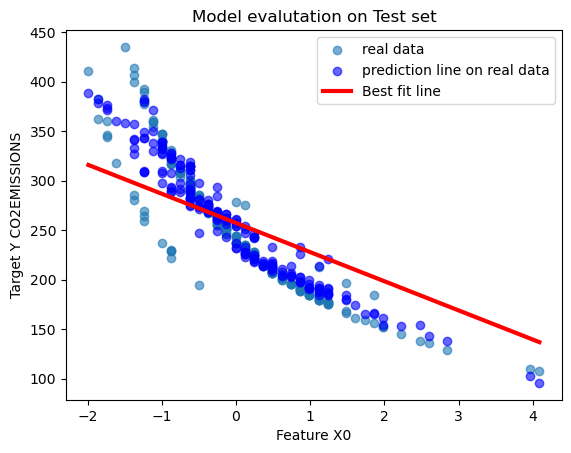

In [38]:
# parametters

coef = model.coef_[0]
intercept = model.intercept_

print(f"coef Feature X0 :FUELCONSUMPTION_COMB_MPG  {coef}")
print(f"intercept Feature X0 :FUELCONSUMPTION_COMB_MPG  {intercept}")


# scatter plots 
plt.scatter(X_test_scaled[:,0], y_test,label = 'real data',alpha = 0.6)  
plt.scatter(X_test_scaled[:,0], y_pred_test,color = 'b', label = "prediction line on real data",alpha = 0.6)

# best-fit line on [:,0] (FUELCONSUMPTION_COMB_MPG)

# creation of the axe X sorted from minimun to maximun of my feature 0 => "FUELCONSUMPTION_COMB_MPG"
x_line = np.linspace(X_test_scaled[:,0].min(), X_test_scaled[:,0].max(),100)

# creation of the test matrix where only my feature 0 => "FUELCONSUMPTION_COMB_MPG" can change while other stay at 0 (their mean)
X_cut = np.zeros((100, X_test_scaled.shape[1]))

X_cut[:,0] = x_line

# prediction of the streath line with my model
y_line = model.predict(X_cut)

# display the line of ajustement of the top
plt.plot(x_line,y_line,color='r',label="Best fit line",linewidth=3)

plt.title("Model evalutation on Test set")
plt.xlabel("Feature X0")
plt.ylabel("Target Y CO2EMISSIONS")
plt.legend()
plt.show()



Evidently, the solution is incredibly poor because the model is trying to fit a plane to a non-planar surface.


Determine and print the parameters for the best-fit linear regression line for CO2 emission with respect to engine size.

In [39]:
# parametters

coef = model.coef_[3]
intercept = model.intercept_

print(f"coef Feature X3 :ENGINESIZE  {coef}")
print(f"intercept Feature X3 :ENGINESIZE  {intercept}")

coef Feature X3 :ENGINESIZE  12.669963204701974
intercept Feature X3 :ENGINESIZE  257.25674091441965


<details><summary>Click here for the solution</summary>

```python   

X_train_1 = X_train[:,0]
regressor_1 = linear_model.LinearRegression()
regressor_1.fit(X_train_1.reshape(-1, 1), y_train)
coef_1 =  regressor_1.coef_
intercept_1 = regressor_1.intercept_
print ('Coefficients: ',coef_1)
print ('Intercept: ',intercept_1)

```

</details>


Produce a scatterplot of CO2 emission against ENGINESIZE and include the best-fit regression line to the training data.


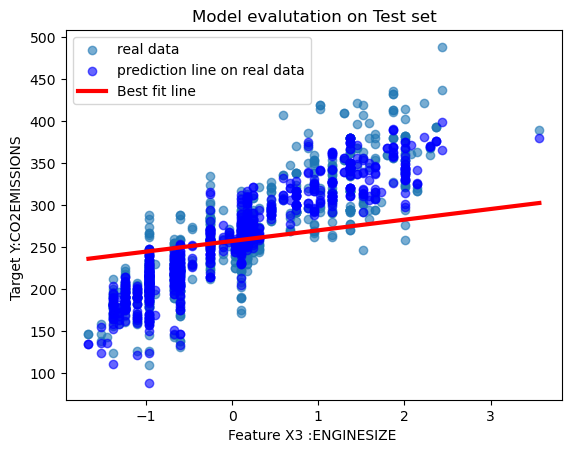

In [40]:




y_pred_train = model.predict(X_train_scaled)


# scatter plots 
plt.scatter(X_train_scaled[:,3], y_train,label = 'real data',alpha = 0.6)  
plt.scatter(X_train_scaled[:,3], y_pred_train,color = 'b', label = "prediction line on real data",alpha = 0.6)

# best-fit line on [:,3] (ENGINESIZE)

# creation of the axe X sorted from minimun to maximun of my feature 3 => "ENGINESIZE"
x_line = np.linspace(X_train_scaled[:,3].min(), X_train_scaled[:,3].max(),100)

# creation of the test matrix where only my feature 3 => "ENGINESIZE" can change while other stay at 0 (their mean)
X_cut = np.zeros((100, X_train_scaled.shape[1]))

X_cut[:,3] = x_line

# prediction of the streath line with my model
y_line = model.predict(X_cut)

# display the line of ajustement of the top
plt.plot(x_line,y_line,color='r',label="Best fit line",linewidth=3)

plt.title("Model evalutation on Test set")
plt.xlabel("Feature X3 :ENGINESIZE ")
plt.ylabel("Target Y:CO2EMISSIONS ")
plt.legend()
plt.show()

<details><summary>Click here for the solution</summary>

```python  
plt.scatter(X_train_1, y_train,  color='blue')
plt.plot(X_train_1, coef_1[0] * X_train_1 + intercept_1, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

```

</details>


Evidently, this simple linear regression model provides a much better fit of CO2 emissions on the training data than the multiple regression model did. Let's see what its performance is on the test data.


Generate the same scatterplot and best-fit regression line, but now base the result on the test data set.
Consider how the test result compares to the training result.

In [41]:
# done see up!

<details><summary>Click here for the solution</summary>

```python  

X_test_1 = X_test[:,0]
plt.scatter(X_test_1, y_test,  color='blue')
plt.plot(X_test_1, coef_1[0] * X_test_1 + intercept_1, '-r')
plt.xlabel("Engine size")
plt.ylabel("CO2 Emission")

```

</details>


Repeat the same modeling but use FUELCONSUMPTION_COMB_MPG as the independent variable instead. Display the model coefficients including the intercept.


In [42]:
# done see up!

<details><summary>Click here for the solution</summary>

```python   
X_train_2 = X_train[:,1]
regressor_2 = linear_model.LinearRegression()
regressor_2.fit(X_train_2.reshape(-1, 1), y_train)
coef_2 =  regressor_2.coef_
intercept_2 = regressor_2.intercept_
print ('Coefficients: ',coef_2)
print ('Intercept: ',intercept_2)
```

</details>


Generate a scatter plot showing the results as before on the test data.
Consider  well the model fits, and what you might be able to do to improve it. We'll revisit this later in the course.


In [43]:
# done up

<details><summary>Click here for the solution</summary>

```python
X_test_2 = X_test[:,1]
plt.scatter(X_test_2, y_test,  color='blue')
plt.plot(X_test_2, coef_2[0] * X_test_2 + intercept_2, '-r')
plt.xlabel("combined Fuel Consumption (MPG)")
plt.ylabel("CO2 Emission")
```

</details>


### Congratulations! You're ready to move on to your next lesson!
## Author

<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>

### Other Contributor(s)

<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" taget="_blank">Abhishek Gagneja</a>

<h3 align="center"> © IBM Corporation. All rights reserved. <h3/>

 
<!--
## Change Log
 
 
|  Date (YYYY-MM-DD) |  Version       | Changed By     | Change Description                  |
|---|---|---|---|
| 2024-10-31         | 3.0            | Jeff Grossman  | Rewrite                             |
| 2020-11-03         | 2.1            | Lakshmi        | Made changes in URL                 |
| 2020-11-03         | 2.1            | Lakshmi        | Made changes in URL                 |
| 2020-08-27         | 2.0            | Lavanya        | Moved lab to course repo in GitLab  |
|   |   |   |   |
